# Heart Disease Prediction — Machine Learning Project

This notebook implements **from scratch (NumPy only)** every stage of the project on the
*Heart Disease* dataset (Kaggle: `johnsmith88/heart-disease-dataset`).
The goal is **binary classification**: does a patient have heart disease (`target=1`) or not (`target=0`)?

## Research questions
1. **Predicting heart disease** — can we predict whether the disease is present from the patient's data?
2. **Comparing models** — which model achieves the best performance?
3. **Feature importance** — which features most affect the prediction, and do the models agree?

## The models (implemented from scratch)
1. **k-Nearest Neighbors** (lecture 10)
2. **Decision Tree** (lecture 11)
3. **AdaBoost** (lecture 8)
4. **Neural Network** — MLP, based on the Perceptron (lecture 6) and logistic regression (lecture 14)

## 1. Setup

In [69]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # make `src` importable

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import data_loader as dl
from src import metrics, evaluation as ev, plots
from src.preprocessing import train_test_split, StandardScaler, kfold_indices
from src.models.knn import KNNClassifier
from src.models.decision_tree import DecisionTreeClassifier
from src.models.adaboost import AdaBoostClassifier
from src.models.neural_network import NeuralNetwork

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print("Environment ready.")

Environment ready.


## 2. Loading the data and describing the dataset

The dataset has 13 medical features (age, sex, chest pain type, blood pressure, cholesterol,
maximum heart rate, and more) and a binary target column. We load the raw version and the
de-duplicated version and compare them.

In [70]:
raw_df = dl.load_data(dedup=False)
df = dl.load_data(dedup=True)          # de-duplicated — used for honest evaluation
X, y, feature_names = dl.get_Xy(df)

summary = dl.dataset_summary()
print("Raw rows:        ", summary["n_rows_raw"])
print("Unique rows:     ", summary["n_rows_unique"])
print("Duplicate rows:  ", summary["n_duplicates"])
print("Missing values:  ", summary["n_missing"])
print("Target (unique): ", summary["target_balance_unique"])
df.head()

Raw rows:         1025
Unique rows:      302
Duplicate rows:   723
Missing values:   0
Target (unique):  {1: 164, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [71]:
# Descriptions of each feature
pd.DataFrame(
    [(c, dl.FEATURE_DESCRIPTIONS[c]) for c in feature_names + ["target"]],
    columns=["feature", "description"],
)

,feature,description
0,age,Age (years)
1,sex,"Sex (1=male, 0=female)"
2,cp,Chest pain type (0-3)
3,trestbps,Resting blood pressure (mm Hg)
4,chol,Serum cholesterol (mg/dl)
5,fbs,Fasting blood sugar > 120 mg/dl (1/0)
6,restecg,Resting ECG result (0-2)
7,thalach,Maximum heart rate achieved
8,exang,Exercise-induced angina (1/0)
9,oldpeak,ST depression induced by exercise


In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.000,54.421,9.048,29.000,48.000,55.500,61.000,77.000
sex,302.000,0.682,0.466,0.000,0.000,1.000,1.000,1.000
cp,302.000,0.964,1.032,0.000,0.000,1.000,2.000,3.000
trestbps,302.000,131.603,17.563,94.000,120.000,130.000,140.000,200.000
chol,302.000,246.500,51.753,126.000,211.000,240.500,274.750,564.000
fbs,302.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,302.000,0.526,0.526,0.000,0.000,1.000,1.000,2.000
thalach,302.000,149.570,22.904,71.000,133.250,152.500,166.000,202.000
exang,302.000,0.328,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,302.000,1.043,1.161,0.000,0.000,0.800,1.600,6.200


## 3. Exploratory Data Analysis (EDA)

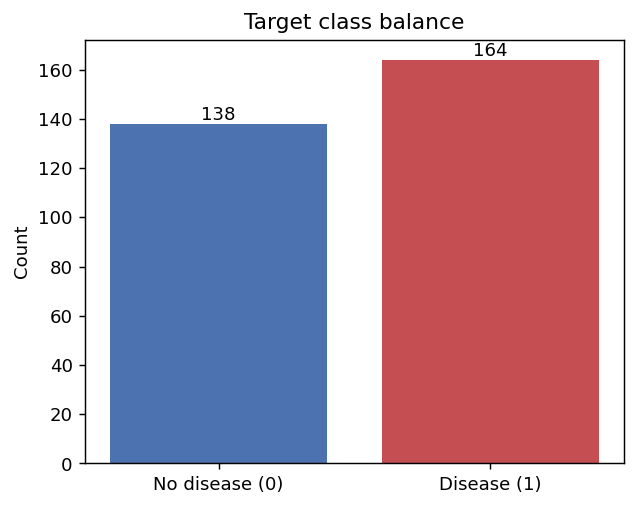

In [73]:
display(Image(plots.plot_class_balance(y)))

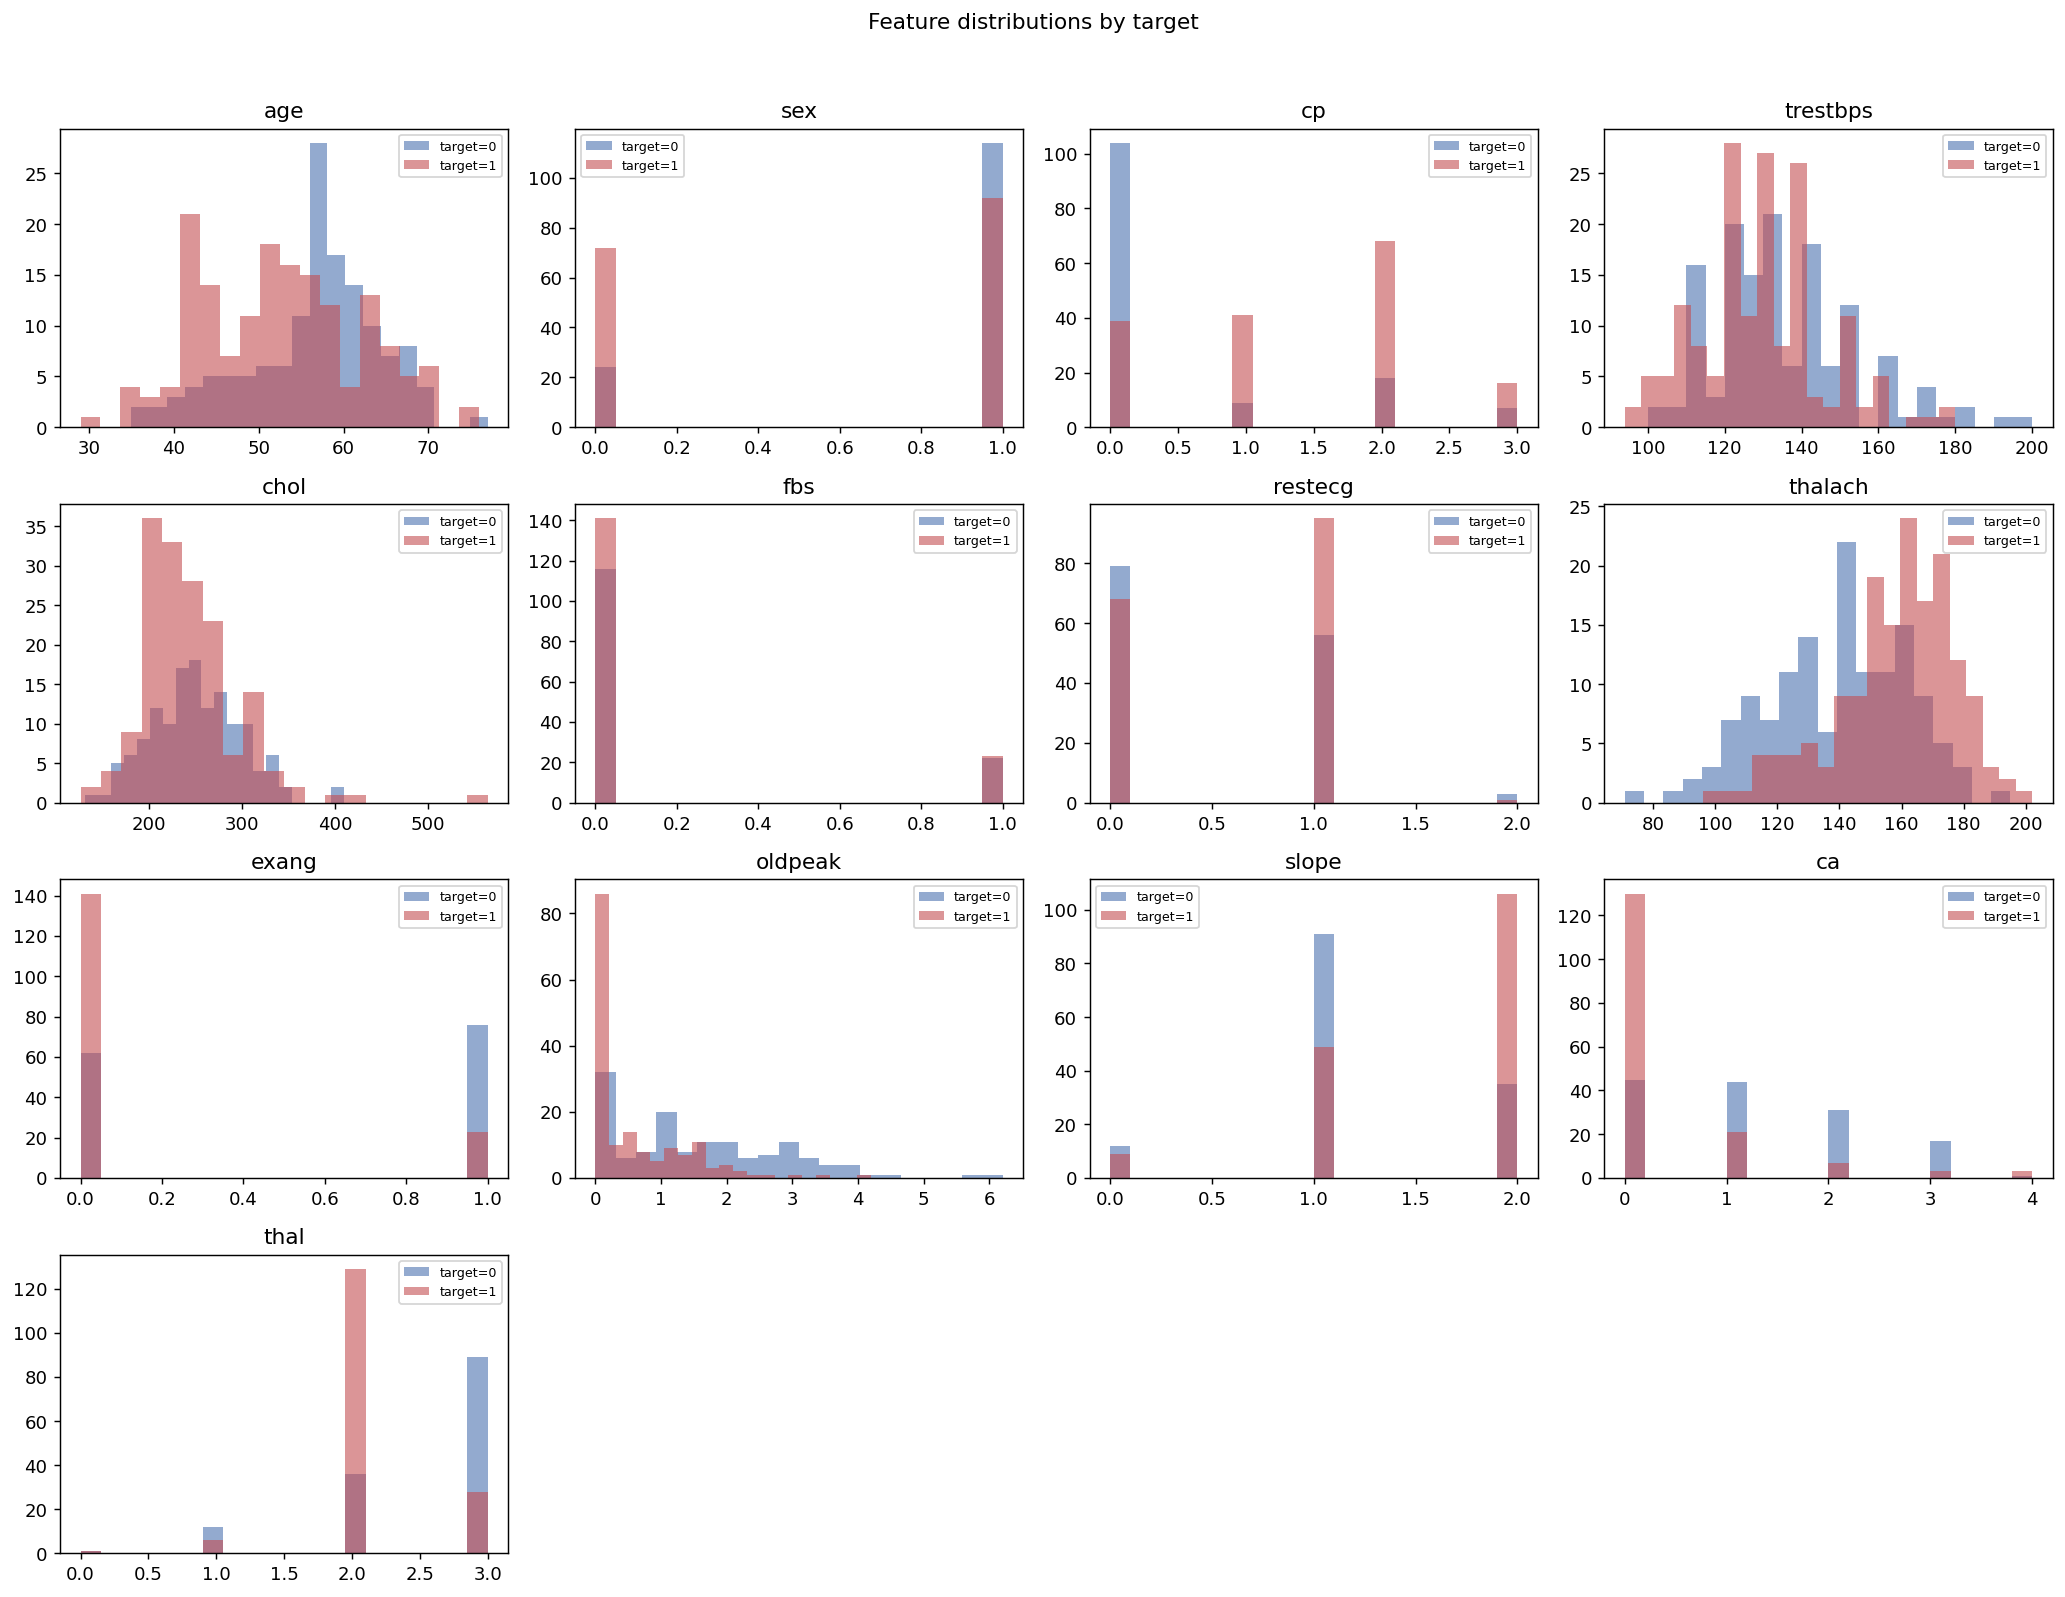

In [74]:
display(Image(plots.plot_feature_histograms(df, feature_names)))

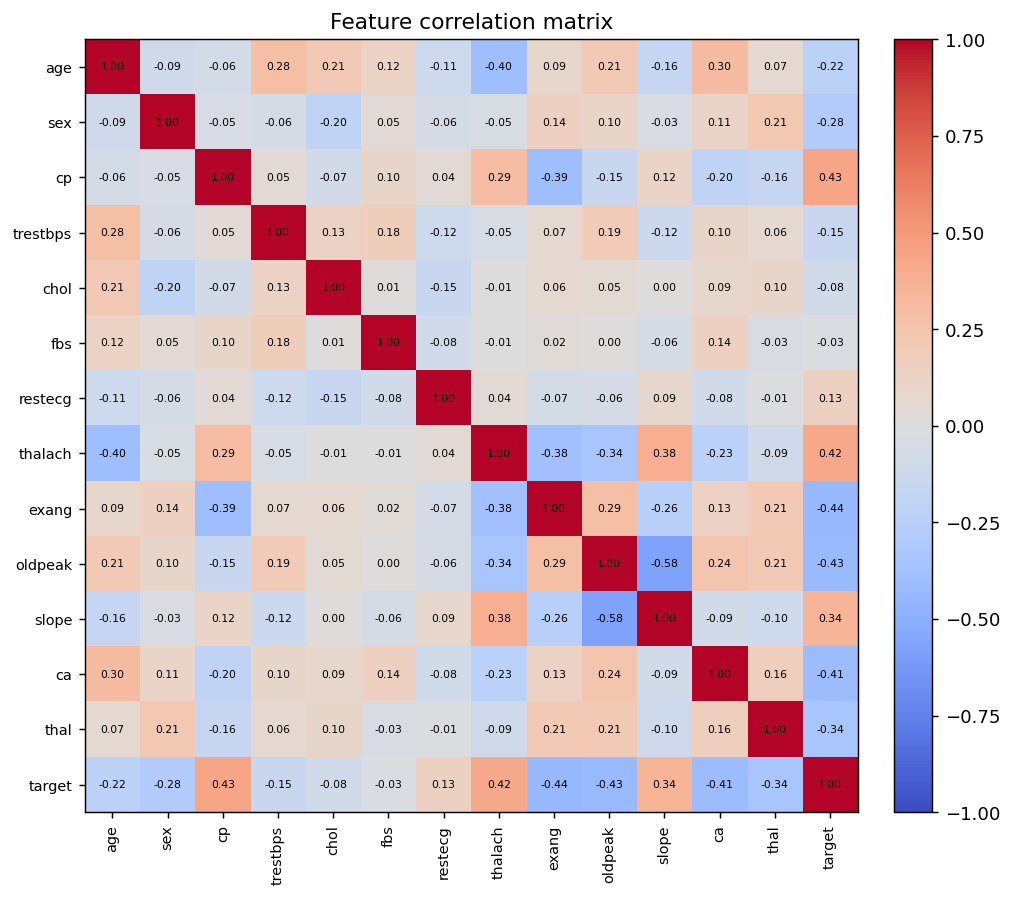

In [75]:
display(Image(plots.plot_correlation_heatmap(df, feature_names + ['target'])))

### 3.1 Dimensionality reduction for visualization (lecture 15)

We project the data to 2-D using a **Johnson–Lindenstrauss random projection** (lecture 15).
The projection shows partial separation between the sick and healthy patients.

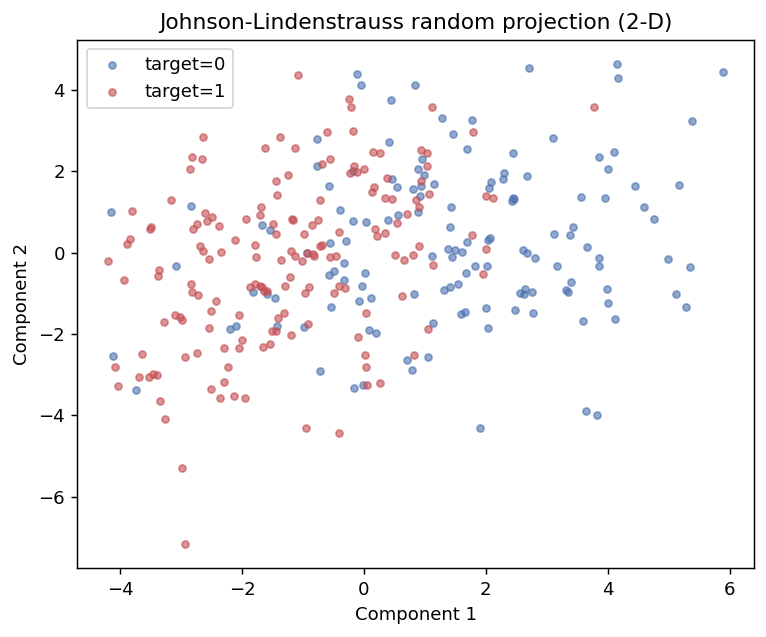

In [76]:
display(Image(plots.plot_2d_projection(X, y)))

## 4. Main challenge: duplicates and data leakage

The Kaggle version contains **723 duplicate rows** (1025 → 302 unique). A random split puts
identical copies in both train and test, so a "memorizing" model gets an inflated accuracy.
We demonstrate this: models that can memorize (1-NN, a full tree) reach 100% on the data with
duplicates, and only a realistic accuracy once they are removed.

In [77]:
X_raw, y_raw, _ = dl.get_Xy(raw_df)      # with duplicates
X_unique, y_unique, _ = dl.get_Xy(df)    # without duplicates

experiments = {
    "1-NN":                 (lambda: KNNClassifier(k=1), True),
    "5-NN":                 (lambda: KNNClassifier(k=5), True),
    "Decision Tree (full)": (lambda: DecisionTreeClassifier(max_depth=None), False),
    "Decision Tree (d=4)":  (lambda: DecisionTreeClassifier(max_depth=4), False),
}

rows = []
for name, (factory, scale) in experiments.items():
    experiment = ev.duplicate_leakage_experiment(
        factory, X_raw, y_raw, X_unique, y_unique, seed=SEED, scale=scale
    )
    rows.append({
        "model": name,
        "acc_with_duplicates": experiment["accuracy_with_duplicates"],
        "acc_deduplicated": experiment["accuracy_deduplicated"],
        "gap": experiment["accuracy_with_duplicates"] - experiment["accuracy_deduplicated"],
    })

leakage_df = pd.DataFrame(rows)
leakage_df

,model,acc_with_duplicates,acc_deduplicated,gap
0,1-NN,1.000,0.770,0.230
1,5-NN,0.873,0.869,0.004
2,Decision Tree (full),1.000,0.787,0.213
3,Decision Tree (d=4),0.854,0.738,0.116


**Conclusion:** the gap (`gap`) demonstrates the leakage. Therefore **all evaluation from here on
uses the de-duplicated data only** — this is the honest way to measure true generalization.

## 5. Preprocessing and splitting

We split into train/test while preserving the class ratio (stratified) and standardize (z-score)
using the train set only. Distance/gradient-based models (k-NN, neural network) use the
standardized data; trees and AdaBoost use the original values (threshold splits are not sensitive
to scale).

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=SEED, stratify=True
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", np.bincount(y_train), " Test balance:", np.bincount(y_test))

Train: (241, 13)  Test: (61, 13)
Train balance: [110 131]  Test balance: [28 33]


## 6. Model 1 — k-Nearest Neighbors (lecture 10)

CV accuracy per k: {1: np.float64(0.768), 3: np.float64(0.776), 5: np.float64(0.796), 7: np.float64(0.801), 9: np.float64(0.796), 11: np.float64(0.809), 15: np.float64(0.809), 21: np.float64(0.792), 31: np.float64(0.792)}
Best k = 11


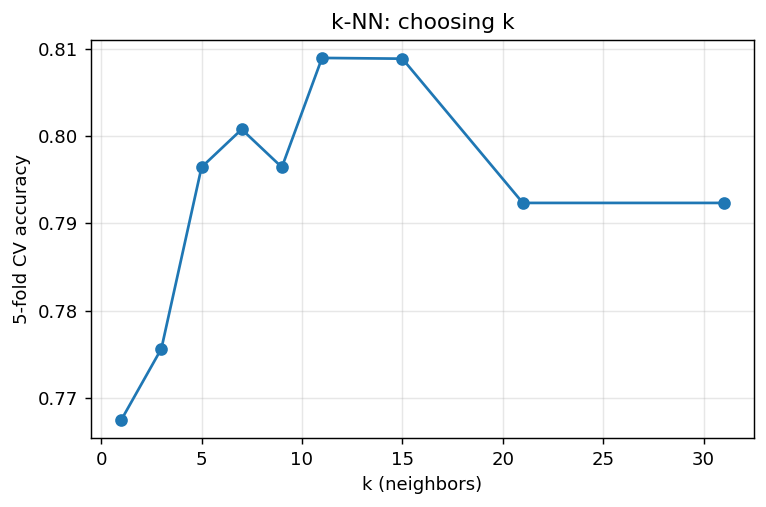

In [79]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_acc = []
for k in k_values:
    scores = ev.cross_val_score(lambda k=k: KNNClassifier(k=k), X_train, y_train,
                                n_splits=5, seed=SEED, scale=True)
    cv_acc.append(scores.mean())

best_k = k_values[int(np.argmax(cv_acc))]
print("CV accuracy per k:", {k: round(a, 3) for k, a in zip(k_values, cv_acc)})
print("Best k =", best_k)
display(Image(plots.plot_curve(k_values, cv_acc, "k (neighbors)",
            "5-fold CV accuracy", "k-NN: choosing k", name="knn_k_curve.png")))

## 7. Model 2 — Decision Tree (lecture 11)

Best max_depth = 5  (CV acc=0.789)


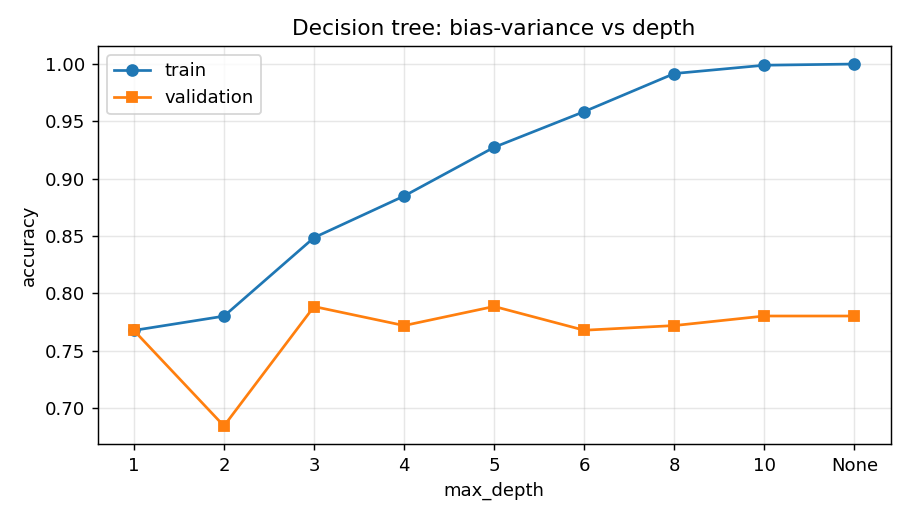

In [80]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_acc = []
val_acc = []
for depth in depths:
    train_scores = []
    val_scores = []
    for train_idx, val_idx in kfold_indices(y_train, n_splits=5, seed=SEED):
        tree = DecisionTreeClassifier(criterion="entropy", max_depth=depth)
        tree.fit(X_train[train_idx], y_train[train_idx])
        train_scores.append(metrics.accuracy(y_train[train_idx], tree.predict(X_train[train_idx])))
        val_scores.append(metrics.accuracy(y_train[val_idx], tree.predict(X_train[val_idx])))
    train_acc.append(np.mean(train_scores))
    val_acc.append(np.mean(val_scores))

labels = [str(depth) if depth is not None else "None" for depth in depths]
best_depth = depths[int(np.argmax(val_acc))]
print("Best max_depth =", best_depth, " (CV acc=%.3f)" % max(val_acc))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, train_acc, "o-", label="train")
ax.plot(labels, val_acc, "s-", label="validation")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Decision tree: bias-variance vs depth")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/tree_depth_curve.png", dpi=130)
plt.close(fig)
display(Image("../figures/tree_depth_curve.png"))

The overfitting curve illustrates the generalization principle from the **PAC and VC-dimension**
lectures: a deeper tree fits the train set almost perfectly (accuracy→1), but the validation
performance starts to drop — too much complexity hurts generalization.

## 8. Model 3 — AdaBoost (lecture 8)

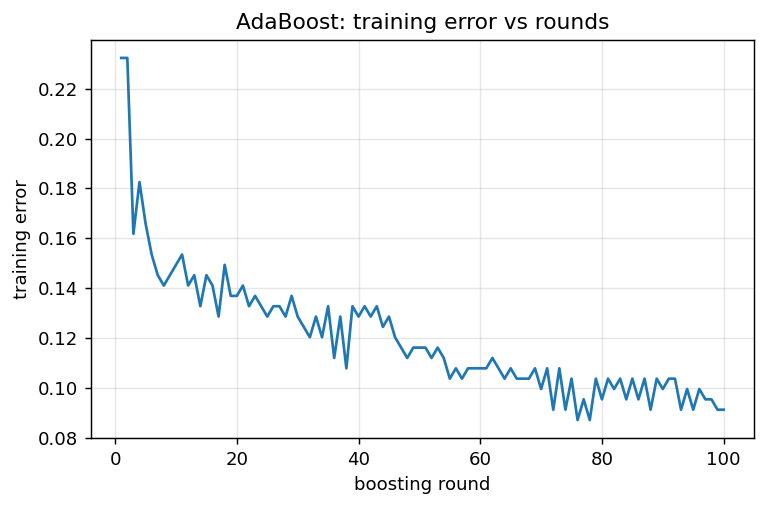

CV accuracy per n_estimators: {1: np.float64(0.768), 5: np.float64(0.788), 10: np.float64(0.805), 20: np.float64(0.793), 30: np.float64(0.793), 50: np.float64(0.784), 75: np.float64(0.772), 100: np.float64(0.768)}
Best n_estimators = 10


In [81]:
ada = AdaBoostClassifier(n_estimators=100).fit(X_train, y_train)
display(Image(plots.plot_curve(range(1, len(ada.train_errors_) + 1),
            ada.train_errors_, "boosting round", "training error",
            "AdaBoost: training error vs rounds", name="adaboost_rounds.png",
            marker="")))

# Choose the number of rounds by 5-fold CV.
round_grid = [1, 5, 10, 20, 30, 50, 75, 100]
cv_round = []
for n_rounds in round_grid:
    scores = ev.cross_val_score(lambda n=n_rounds: AdaBoostClassifier(n_estimators=n),
                                X_train, y_train, n_splits=5, seed=SEED, scale=False)
    cv_round.append(scores.mean())
best_n_rounds = round_grid[int(np.argmax(cv_round))]
print("CV accuracy per n_estimators:", {n: round(acc, 3) for n, acc in zip(round_grid, cv_round)})
print("Best n_estimators =", best_n_rounds)

The AdaBoost training-error bound from lecture 8 is $\prod_t 2\sqrt{\epsilon_t(1-\epsilon_t)}$,
so the training error decreases (almost) monotonically with the number of rounds — as the curve shows.

## 9. Model 4 — Neural Network (MLP, lectures 6 and 14)

Numerical gradient check (relative diff) = 5.02e-10  -> PASS
Final training loss = 0.0567
Test accuracy = 0.754


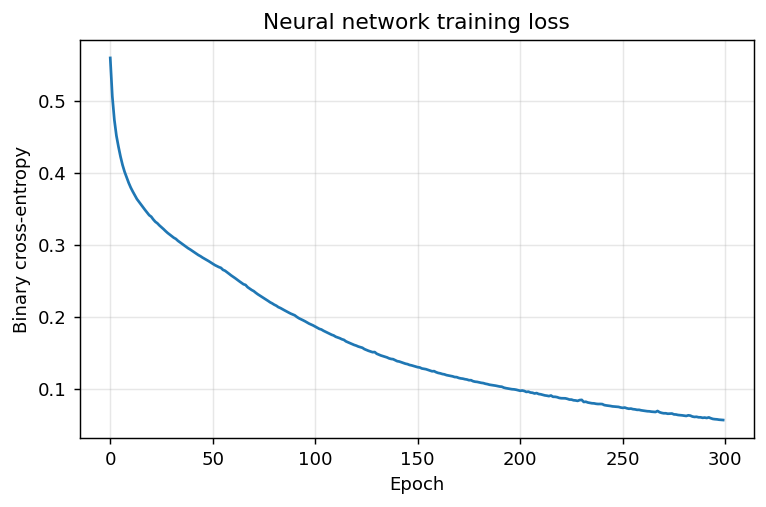

In [82]:
# Verify back-propagation with a numerical gradient check.
grad_diff = NeuralNetwork(hidden_layers=(8,), seed=0).gradient_check(X_train_s[:20], y_train[:20])
print(f"Numerical gradient check (relative diff) = {grad_diff:.2e}  -> {'PASS' if grad_diff < 1e-5 else 'FAIL'}")

nn = NeuralNetwork(hidden_layers=(16,), activation="relu", lr=0.1,
                   epochs=300, batch_size=32, l2=1e-4, seed=SEED)
nn.fit(X_train_s, y_train)
print("Final training loss = %.4f" % nn.loss_history_[-1])
print("Test accuracy = %.3f" % metrics.accuracy(y_test, nn.predict(X_test_s)))
display(Image(plots.plot_nn_loss(nn.loss_history_)))

## 10. Model comparison (research question 2)

In [83]:
# Final tuned models.
final_models = {
    "k-NN":          (lambda: KNNClassifier(k=best_k), True),
    "Decision Tree": (lambda: DecisionTreeClassifier(criterion="entropy", max_depth=best_depth), False),
    "AdaBoost":      (lambda: AdaBoostClassifier(n_estimators=best_n_rounds), False),
    "Neural Net":    (lambda: NeuralNetwork(hidden_layers=(16,), lr=0.1, epochs=300,
                                            batch_size=32, l2=1e-4, seed=SEED), True),
}

results = {}
fitted = {}
for name, (factory, scale) in final_models.items():
    X_fit, X_eval = (X_train_s, X_test_s) if scale else (X_train, X_test)
    model = factory()
    model.fit(X_fit, y_train)
    fitted[name] = (model, scale)
    results[name] = ev.evaluate_model(model, X_fit, y_train, X_eval, y_test)

results_df = pd.DataFrame(results).T[["accuracy"]]
results_df = results_df.sort_values("accuracy", ascending=False)
results_df

,accuracy
k-NN,0.885
Decision Tree,0.787
AdaBoost,0.787
Neural Net,0.754


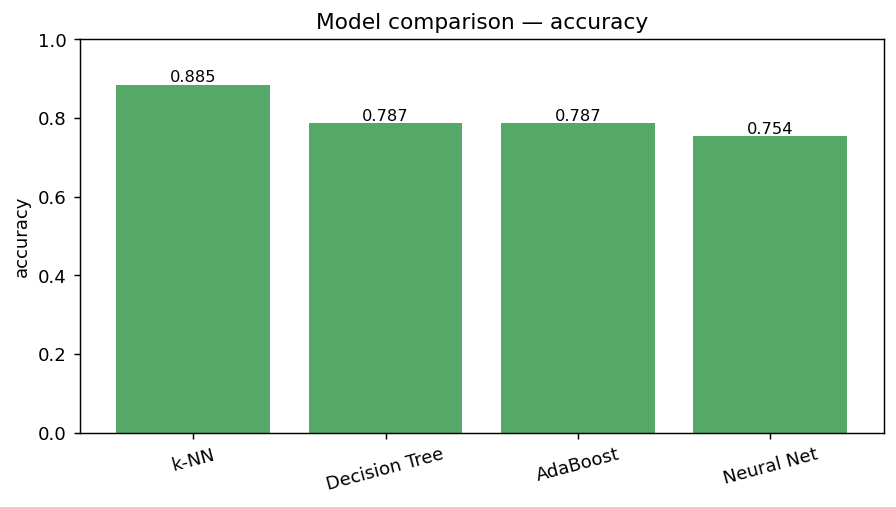

Best model: k-NN (accuracy = 0.885)


In [84]:
display(Image(plots.plot_model_comparison(results, metric="accuracy")))
best_name = results_df.index[0]
print("Best model:", best_name, "(accuracy = %.3f)" % results_df.loc[best_name, "accuracy"])

## 11. Feature importance (research question 3)

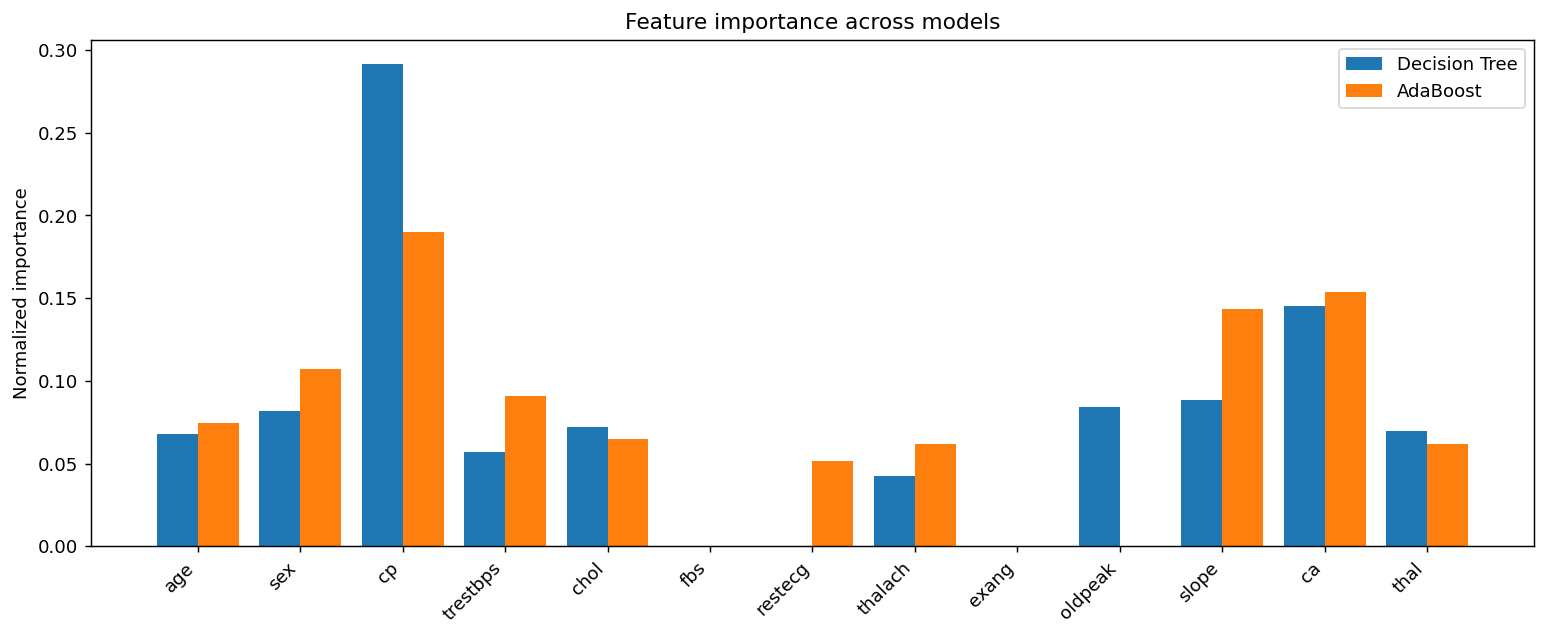

,Decision Tree,AdaBoost,mean
cp,0.292,0.190,0.241
ca,0.145,0.154,0.150
slope,0.089,0.143,0.116
sex,0.082,0.107,0.094
trestbps,0.057,0.091,0.074
age,0.068,0.074,0.071
chol,0.072,0.065,0.069
thal,0.069,0.062,0.066
thalach,0.042,0.062,0.052
oldpeak,0.084,0.000,0.042


In [85]:
importances = {}

# Model-specific importances (impurity decrease in the tree, stump weights in AdaBoost).
dt_full = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth).fit(X_train, y_train)
importances["Decision Tree"] = dt_full.feature_importances_
importances["AdaBoost"] = fitted["AdaBoost"][0].feature_importances_

display(Image(plots.plot_feature_importances(importances, feature_names)))

# Average the normalized importances across models to get a consensus.
normalized = {}
for model_name, importance in importances.items():
    importance = np.asarray(importance)
    normalized[model_name] = importance / (np.sum(np.abs(importance)) or 1)

imp_df = pd.DataFrame(normalized, index=feature_names)
imp_df["mean"] = imp_df.mean(axis=1)
imp_df.sort_values("mean", ascending=False)

## 12. Answers to the research questions

**1. Predicting heart disease.** Yes — after removing the duplicates, all models achieve accuracy
significantly above 50% (the random baseline), so heart disease can be predicted from the patient's
data at a useful level of accuracy.

**2. Comparing models.** See the results table and chart in section 10. The leading model is
identified automatically (`best_name`) by test accuracy.

**3. Feature importance.** See section 11. The features that recur as important for both models
(e.g. `cp`, `ca`, `slope`, `sex`) point to partial agreement between the methods, even though each
model weighs them slightly differently.

## 13. Challenges and lessons
- **Duplicate leakage** was the main challenge; we handled it by removing duplicates and evaluating honestly.
- **Standardization** was critical for k-NN and the neural network, and irrelevant for trees/AdaBoost.
- **Overfitting** in trees and in the number of AdaBoost rounds was controlled with cross-validation.
- **Gradient checking** in the neural network verified the correctness of the back-propagation.

The full conclusions are in the report files in the `reports/` folder.